In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer

# Load the dataset
train_df = pd.read_csv('train.csv', index_col='id')

print(f"train shape: {train_df.shape}")
train_df.head()

train shape: (594194, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [2]:
schema_df = pd.DataFrame(
    {
        "dtype": train_df.dtypes,
        "missing_train": train_df.isna().sum(),
    }
)

schema_df

,dtype,missing_train
gender,object,0
SeniorCitizen,int64,0
Partner,object,0
Dependents,object,0
tenure,int64,0
PhoneService,object,0
MultipleLines,object,0
InternetService,object,0
OnlineSecurity,object,0
OnlineBackup,object,0


In [3]:
y = train_df['Churn'].map({'Yes': 1, 'No': 0})
train_df['SeniorCitizen'] = train_df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
X = train_df.drop(columns=['Churn'])

print(f"Churn distribution:\n{y.value_counts(normalize=True)}")

Churn distribution:
Churn
0    0.774792
1    0.225208
Name: proportion, dtype: float64


In [4]:
# Defining Feature groups

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Numeric features count: {len(numeric_features)}")
print(f"Categorical features count: {len(categorical_features)}")
print(f"categorical_features: {categorical_features}")

Numeric features count: 3
Categorical features count: 16
categorical_features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}, y_valid shape: {y_valid.shape}")
print("---------------------------------")
print(f"\nTraining set Churn distribution:\n{y_train.value_counts(normalize=True)}")
print("---------------------------------")
print(f"\nValidation set Churn distribution:\n{y_valid.value_counts(normalize=True)}")

X_train shape: (475355, 19), y_train shape: (475355,)
X_valid shape: (118839, 19), y_valid shape: (118839,)
---------------------------------

Training set Churn distribution:
Churn
0    0.774791
1    0.225209
Name: proportion, dtype: float64
---------------------------------

Validation set Churn distribution:
Churn
0    0.774796
1    0.225204
Name: proportion, dtype: float64


In [6]:
# Building the preprocessing pipeline

numeric_features = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_features, ['tenure', 'MonthlyCharges', 'TotalCharges']),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [7]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_valid_preprocessed = preprocessor.transform(X_valid)

print("processed train shape:", X_train_preprocessed.shape)
print("processed valid shape:", X_valid_preprocessed.shape)

processed train shape: (475355, 46)
processed valid shape: (118839, 46)


In [8]:
# Training a XGBoost model

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42)
        )
    ]
)

xgboost_model.fit(X_train, y_train)
xgboost_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [9]:
# Evaluating the XGBoost model
y_pred_xgboost = xgboost_model.predict(X_valid)
y_pred_xgboost_proba = xgboost_model.predict_proba(X_valid)[:, 1]

pd.DataFrame(
    {
        "actual": y_valid.values,
        "predicted": y_pred_xgboost,
        "predicted_probability": y_pred_xgboost_proba
    }
).head()

,actual,predicted,predicted_probability
0,1,1,0.595834
1,0,0,0.001502
2,0,0,0.023506
3,1,1,0.573841
4,0,0,0.101189


In [10]:
cm = confusion_matrix(y_valid, y_pred_xgboost)

print("Classification Report:\n", classification_report(y_valid, y_pred_xgboost))
print("Confusion Matrix:\n", cm)

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.64      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

Confusion Matrix:
 [[85022  7054]
 [ 9595 17168]]


In [11]:


threshold_grid = np.arange(0.10, 0.91, 0.05)

threshold_results = []
for threshold in threshold_grid:
    y_pred_at_threshold = (y_pred_xgboost_proba >= threshold).astype(int)
    threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(y_valid, y_pred_at_threshold, zero_division=0),
            "recall": recall_score(y_valid, y_pred_at_threshold, zero_division=0),
            "f1": f1_score(y_valid, y_pred_at_threshold, zero_division=0),
            "predicted_positive_rate": y_pred_at_threshold.mean(),
        }
    )

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(4)


,threshold,precision,recall,f1,predicted_positive_rate
0,0.10,0.4654,0.9549,0.6258,0.4620
1,0.15,0.5098,0.9260,0.6576,0.4091
2,0.20,0.5443,0.8968,0.6775,0.3710
3,0.25,0.5748,0.8614,0.6895,0.3375
4,0.30,0.6016,0.8295,0.6974,0.3105
5,0.35,0.6286,0.7888,0.6996,0.2826
6,0.40,0.6552,0.7494,0.6991,0.2576
7,0.45,0.6807,0.7010,0.6907,0.2319
8,0.50,0.7088,0.6415,0.6735,0.2038
9,0.55,0.7387,0.5834,0.6520,0.1779


In [12]:
best_threshold_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
best_threshold_row.round(4)


threshold                  0.3500
precision                  0.6286
recall                     0.7888
f1                         0.6996
predicted_positive_rate    0.2826
Name: 5, dtype: float64

In [13]:
boosted_best_threshold = float(best_threshold_row["threshold"])
boosted_valid_pred_best_f1 = (y_pred_xgboost_proba >= boosted_best_threshold).astype(int)

pd.Series(
    {
        "threshold": boosted_best_threshold,
        "precision": precision_score(y_valid, boosted_valid_pred_best_f1),
        "recall": recall_score(y_valid, boosted_valid_pred_best_f1),
        "f1": f1_score(y_valid, boosted_valid_pred_best_f1),
    },
    name=f"{xgboost_model} best-F1 threshold",
).round(4)


threshold    0.3500
precision    0.6286
recall       0.7888
f1           0.6996
Name: Pipeline(steps=[('preprocessor',\n                 ColumnTransformer(transformers=[('num',\n                                                  Pipeline(steps=[('imputer',\n                                                                   SimpleImputer(strategy='median')),\n                                                                  ('scaler',\n                                                                   StandardScaler())]),\n                                                  ['tenure', 'MonthlyCharges',\n                                                   'TotalCharges']),\n                                                 ('cat',\n                                                  Pipeline(steps=[('imputer',\n                                                                   SimpleImputer(strategy='most_frequent')),\n                                                                  ('onehot',

In [14]:
feature_names = xgboost_model.named_steps["preprocessor"].get_feature_names_out()
feature_names[:10], len(feature_names)

(array(['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges',
        'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_No',
        'cat__SeniorCitizen_Yes', 'cat__Partner_No', 'cat__Partner_Yes',
        'cat__Dependents_No'], dtype=object),
 46)

In [15]:
feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": xgboost_model.named_steps["classifier"].feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
37,cat__Contract_Month-to-month,0.565038
17,cat__InternetService_Fiber optic,0.258450
44,cat__PaymentMethod_Electronic check,0.056346
39,cat__Contract_Two year,0.019718
38,cat__Contract_One year,0.012472
16,cat__InternetService_DSL,0.009829
19,cat__OnlineSecurity_No,0.009575
0,num__tenure,0.009488
31,cat__StreamingTV_No,0.007344
34,cat__StreamingMovies_No,0.007046


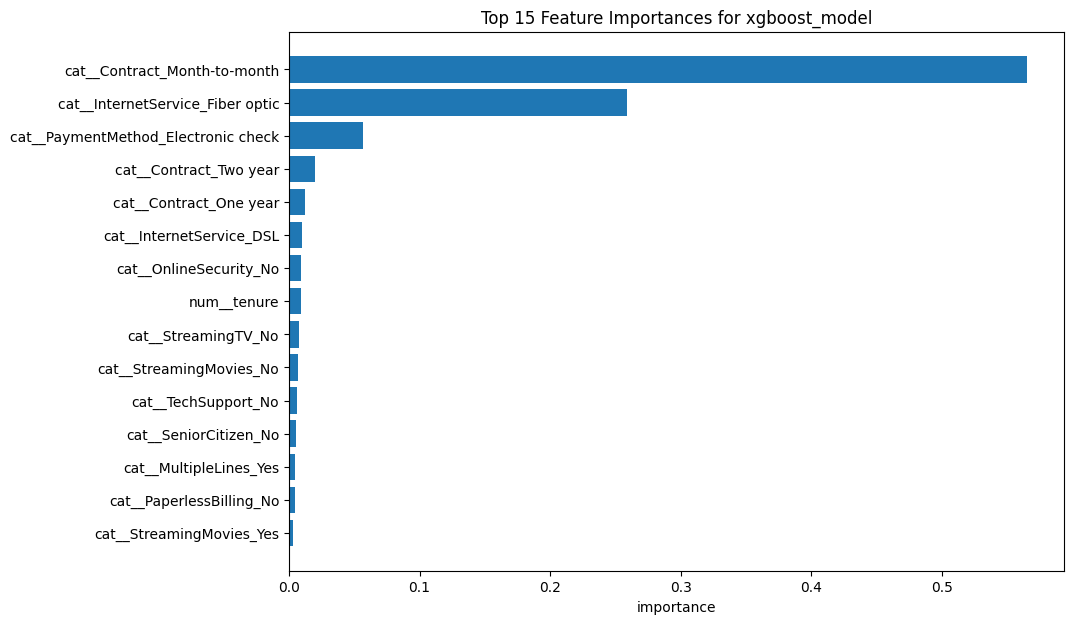

In [18]:
top_n = 15
plot_df = feature_importance_df.head(top_n).sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_title(f"Top {top_n} Feature Importances for xgboost_model")
ax.set_xlabel("importance")
plt.show()

In [19]:
def raw_feature_name(processed_feature_name: str) -> str:
    if processed_feature_name.startswith("num__"):
        return processed_feature_name.replace("num__", "")
    if processed_feature_name.startswith("cat__"):
        remainder = processed_feature_name.replace("cat__", "")
        for col in categorical_features:
            prefix = f"{col}_"
            if remainder.startswith(prefix):
                return col
        return remainder
    return processed_feature_name

feature_importance_df["raw_feature"] = feature_importance_df["feature"].map(raw_feature_name)
raw_feature_importance_df = (
    feature_importance_df.groupby("raw_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

raw_feature_importance_df.head(15)


,raw_feature,importance
0,Contract,0.597228
3,InternetService,0.269080
10,PaymentMethod,0.057659
13,StreamingMovies,0.010490
7,OnlineSecurity,0.010324
18,tenure,0.009488
14,StreamingTV,0.009412
5,MultipleLines,0.007581
15,TechSupport,0.006579
12,SeniorCitizen,0.005705
